In [29]:
# load seqs, annotations, and the K562 pred_koo encoder
import numpy as np, pandas as pd, matplotlib.pyplot as plt, sys
from pathlib import Path

FG_ROOT = Path('/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq/foregrounds')
LIB     = Path('/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq/mutagenesis_lib')
SIT     = Path('/grid/koo/home/pmantill/projects/situate')

_raw  = pd.read_csv(SIT / 'edits.csv')
_seam = _raw[_raw.sequence_name.str.startswith('SEAM:K562:', na=False)
             & _raw.sequence_name.str.endswith(':foreground_scaled', na=False)].copy()
_seam['peak'] = _seam.sequence_name.str.split(':').str[2]
ann = _seam.assign(sequence_name=_seam['peak'])
PEAK_TO_ANNROW = {p: p for p in ann['peak'].unique()}
finished = sorted(d.name for d in FG_ROOT.iterdir()
                  if d.is_dir() and (d / 'foreground_scaled.npy').exists())
ko_peaks = [p for p in finished if p in PEAK_TO_ANNROW]

sys.path.insert(0, '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/'
                   'Hippo_dependency_chromatin-accessibility/alphagenome-encoder-ft/src')
import h5py, torch
from tangermeme.utils import one_hot_encode
from tangermeme.ersatz import dinucleotide_shuffle
from alphagenome_encoder_ft import EncoderMPRAModel

N_REP  = 30
CKPT   = '/grid/koo/home/shared/models/alphagenome_encoder/torch/mpra_K562/finetuned_encoder.pt'
model  = EncoderMPRAModel.from_checkpoint(CKPT, device='cuda').eval()
cfg    = torch.load(CKPT, map_location='cpu', weights_only=False)['construct_config']
suffix = one_hot_encode(cfg['promoter_seq'] + cfg['barcode_seq']).float()   # promoter+barcode

@torch.no_grad()
def predict_k562(insert_ohe):                       # (B,4,230) -> (B,)
    x = torch.cat([insert_ohe, suffix.expand(len(insert_ohe), -1, -1)], 2)  # (B,4,281)
    return model(x.transpose(1, 2).cuda()).cpu().numpy()

def load_peak(peak):
    with h5py.File(LIB / f'{peak}.h5') as f:
        wt_str = f.attrs['wt_seq_str']; ADAPTER = int(f.attrs['var_start'])
    wt    = one_hot_encode(wt_str).float()                 # (4,230)
    mmask = np.zeros(200, bool)                             # motif positions in var-region coords
    for _, m in ann[ann.sequence_name == PEAK_TO_ANNROW[peak]].iterrows():
        mmask[m.start:m.end] = True
    return wt, ADAPTER, mmask

print(len(ko_peaks), 'annotated peaks:', ko_peaks)

8 annotated peaks: ['ENSG00000143384', 'peak10288_Reversed', 'peak20130', 'peak26256', 'peak27535_Reversed', 'peak38192_Reversed', 'peak49966_Reversed', 'peak84030']


In [30]:
# reference conditions per peak (N_REP dinuc-shuffles each): WT, ms KO (motifs shuffled,
# context WT), context KO (whole context shuffled, motifs WT). The random-4bp screen below
# is plotted against these.
def shuffle_at(wt, ADAPTER, pos, rs):
    """WT with the positions in `pos` (bool[200]) dinuc-shuffled at the same positions -> (N_REP,)."""
    shuf = dinucleotide_shuffle(wt[:, ADAPTER:ADAPTER + 200].unsqueeze(0), n=N_REP, random_state=rs)[0]
    sel  = np.where(pos)[0]
    x = wt.unsqueeze(0).repeat(N_REP, 1, 1).clone()
    x[:, :, sel + ADAPTER] = shuf[:, :, sel]
    return predict_k562(x)

wt_pred, msko_pred, ctxko_pred = {}, {}, {}
for peak in ko_peaks:
    wt, ADAPTER, mmask = load_peak(peak)
    wt_pred[peak]    = float(predict_k562(wt.unsqueeze(0))[0])
    msko_pred[peak]  = shuffle_at(wt, ADAPTER,  mmask, rs=0)      # motifs shuffled, context WT
    ctxko_pred[peak] = shuffle_at(wt, ADAPTER, ~mmask, rs=0)      # whole context shuffled, motifs WT
    print(f'{peak:24s} WT={wt_pred[peak]:+.3f}  msKO={msko_pred[peak].mean():+.3f}  '
          f'ctxKO={ctxko_pred[peak].mean():+.3f}')

ENSG00000143384          WT=+1.414  msKO=-0.196  ctxKO=+1.046
peak10288_Reversed       WT=+1.640  msKO=-0.432  ctxKO=+0.926
peak20130                WT=+1.358  msKO=-0.271  ctxKO=+0.602


peak26256                WT=+1.732  msKO=-0.448  ctxKO=+1.127
peak27535_Reversed       WT=+1.765  msKO=-0.543  ctxKO=+0.458
peak38192_Reversed       WT=+1.402  msKO=-0.267  ctxKO=+0.840
peak49966_Reversed       WT=+1.582  msKO=-0.430  ctxKO=+1.296
peak84030                WT=+1.795  msKO=-0.029  ctxKO=+0.778


In [31]:
# greedy random-4bp screen: 20 rounds, each = 10 random attempts of a 30-rep KO. Each attempt
# adds one random 4bp window (off motifs) to the already-shuffled positions; the window that
# lowers predicted activity most is kept and carried into the next round.
N_ROUNDS, N_ATTEMPTS, WIN = 20, 10, 4
screen, screen_pos, screen_win = {}, {}, {}          # peak -> per-round (N_REP,) preds / accumulated bool[200] / chosen 4bp start
for peak in ko_peaks:
    wt, ADAPTER, mmask = load_peak(peak)
    starts = [s for s in range(200 - WIN + 1) if not mmask[s:s + WIN].any()]   # 4bp windows off motifs
    rng    = np.random.default_rng(0)
    chosen = np.zeros(200, bool)
    rounds, pos_hist, win_hist = [], [], []
    for _ in range(N_ROUNDS):
        best = None
        for _ in range(N_ATTEMPTS):
            s = int(rng.choice(starts))
            cand = chosen.copy(); cand[s:s + WIN] = True
            preds = shuffle_at(wt, ADAPTER, cand, rs=int(rng.integers(1 << 30)))
            if best is None or preds.mean() < best[0]:   # maximally lowering KO
                best = (preds.mean(), preds, cand, s)
        chosen = best[2]
        rounds.append(best[1]); pos_hist.append(chosen.copy()); win_hist.append(best[3])
    screen[peak], screen_pos[peak], screen_win[peak] = rounds, pos_hist, win_hist
    print(f'{peak:24s} ' + '  '.join(f'R{i+1}={r.mean():+.3f}' for i, r in enumerate(rounds))
          + f'   (ctxKO={ctxko_pred[peak].mean():+.3f})')

ENSG00000143384          R1=+1.341  R2=+1.299  R3=+1.178  R4=+1.097  R5=+0.988  R6=+0.959  R7=+0.977  R8=+0.696  R9=+0.619  R10=+0.506  R11=+0.484  R12=+0.563  R13=+0.553  R14=+0.549  R15=+0.476  R16=+0.319  R17=+0.468  R18=+0.525  R19=+0.477  R20=+0.458   (ctxKO=+1.046)
peak10288_Reversed       R1=+1.503  R2=+1.429  R3=+1.407  R4=+1.278  R5=+1.222  R6=+1.197  R7=+1.042  R8=+0.918  R9=+0.940  R10=+0.938  R11=+0.944  R12=+0.905  R13=+0.868  R14=+0.814  R15=+0.754  R16=+0.830  R17=+0.655  R18=+0.586  R19=+0.542  R20=+0.554   (ctxKO=+0.926)
peak20130                R1=+1.213  R2=+1.032  R3=+0.825  R4=+0.641  R5=+0.485  R6=+0.339  R7=+0.279  R8=+0.314  R9=+0.210  R10=+0.278  R11=+0.119  R12=+0.043  R13=+0.101  R14=+0.110  R15=+0.081  R16=+0.194  R17=+0.185  R18=+0.045  R19=+0.146  R20=+0.109   (ctxKO=+0.602)
peak26256                R1=+1.689  R2=+1.661  R3=+1.617  R4=+1.549  R5=+1.494  R6=+1.490  R7=+1.424  R8=+1.446  R9=+1.364  R10=+1.381  R11=+1.311  R12=+1.288  R13=+1.263  R14=+1.139  

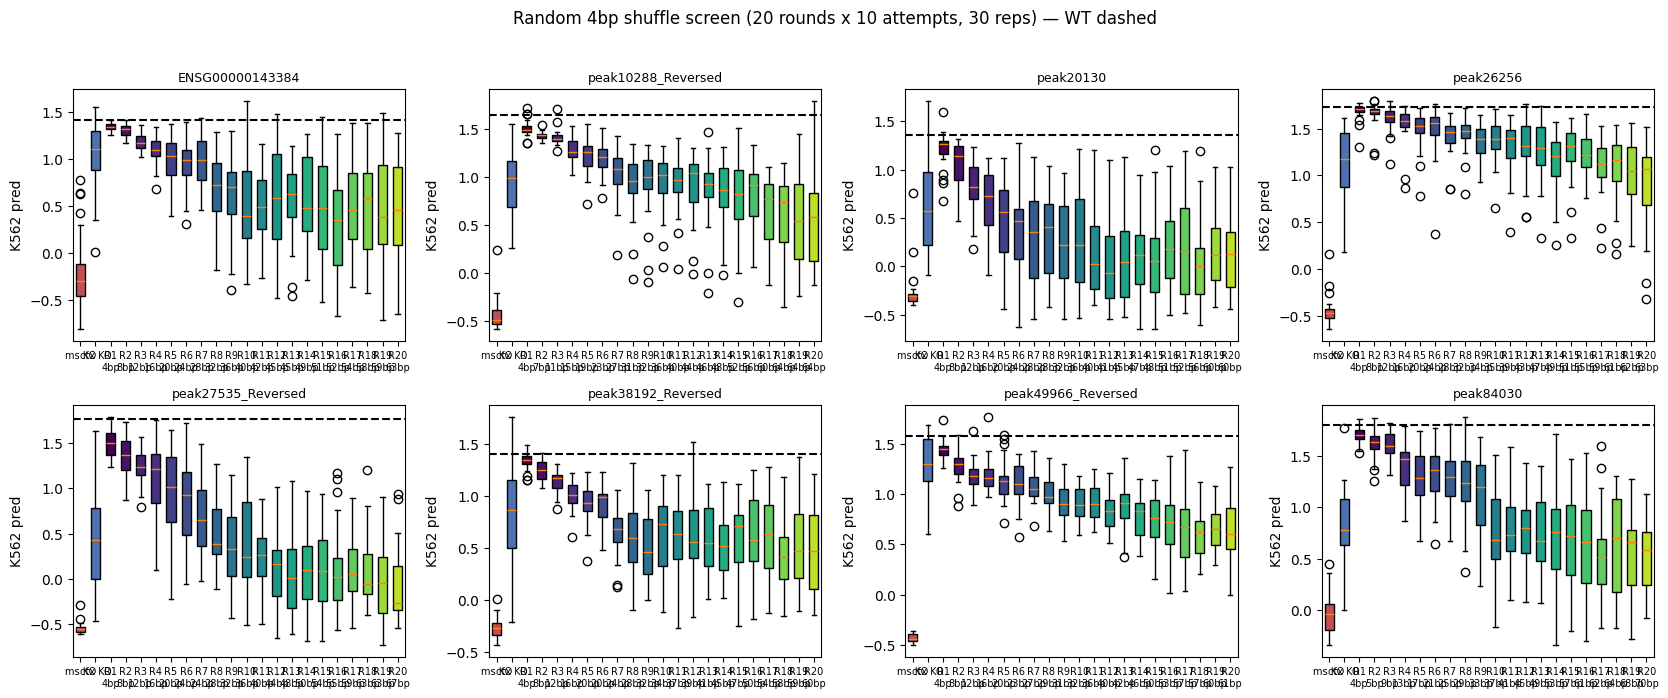

In [32]:
# per peak: predicted activity across screen rounds next to ms KO / context KO, WT dashed.
# does accumulating a few 4bp shuffles (smaller subseq) reproduce the full context-KO drop?
ncol = 4; nrow = int(np.ceil(len(ko_peaks) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.4 * nrow), squeeze=False)
round_c = plt.cm.viridis(np.linspace(0, 0.9, N_ROUNDS))
for ax, peak in zip(axes.ravel(), ko_peaks):
    data = [msko_pred[peak], ctxko_pred[peak]] + screen[peak]
    labs = ['ms KO', 'ctx KO'] + [f'R{i+1}\n{int(p.sum())}bp' for i, p in enumerate(screen_pos[peak])]
    cols = ['#c44e52', '#4c72b0'] + list(round_c)
    b = ax.boxplot(data, patch_artist=True, widths=0.6)
    for box, c in zip(b['boxes'], cols):
        box.set_facecolor(c)
    ax.axhline(wt_pred[peak], color='k', lw=1.5, ls='--')
    ax.set_xticks(range(1, len(labs) + 1)); ax.set_xticklabels(labs, fontsize=7)
    ax.set_title(peak, fontsize=9); ax.set_ylabel('K562 pred')
for ax in axes.ravel()[len(ko_peaks):]:
    ax.axis('off')
fig.suptitle(f'Random 4bp shuffle screen ({N_ROUNDS} rounds x {N_ATTEMPTS} attempts, {N_REP} reps) — WT dashed', y=1.02)
fig.tight_layout()

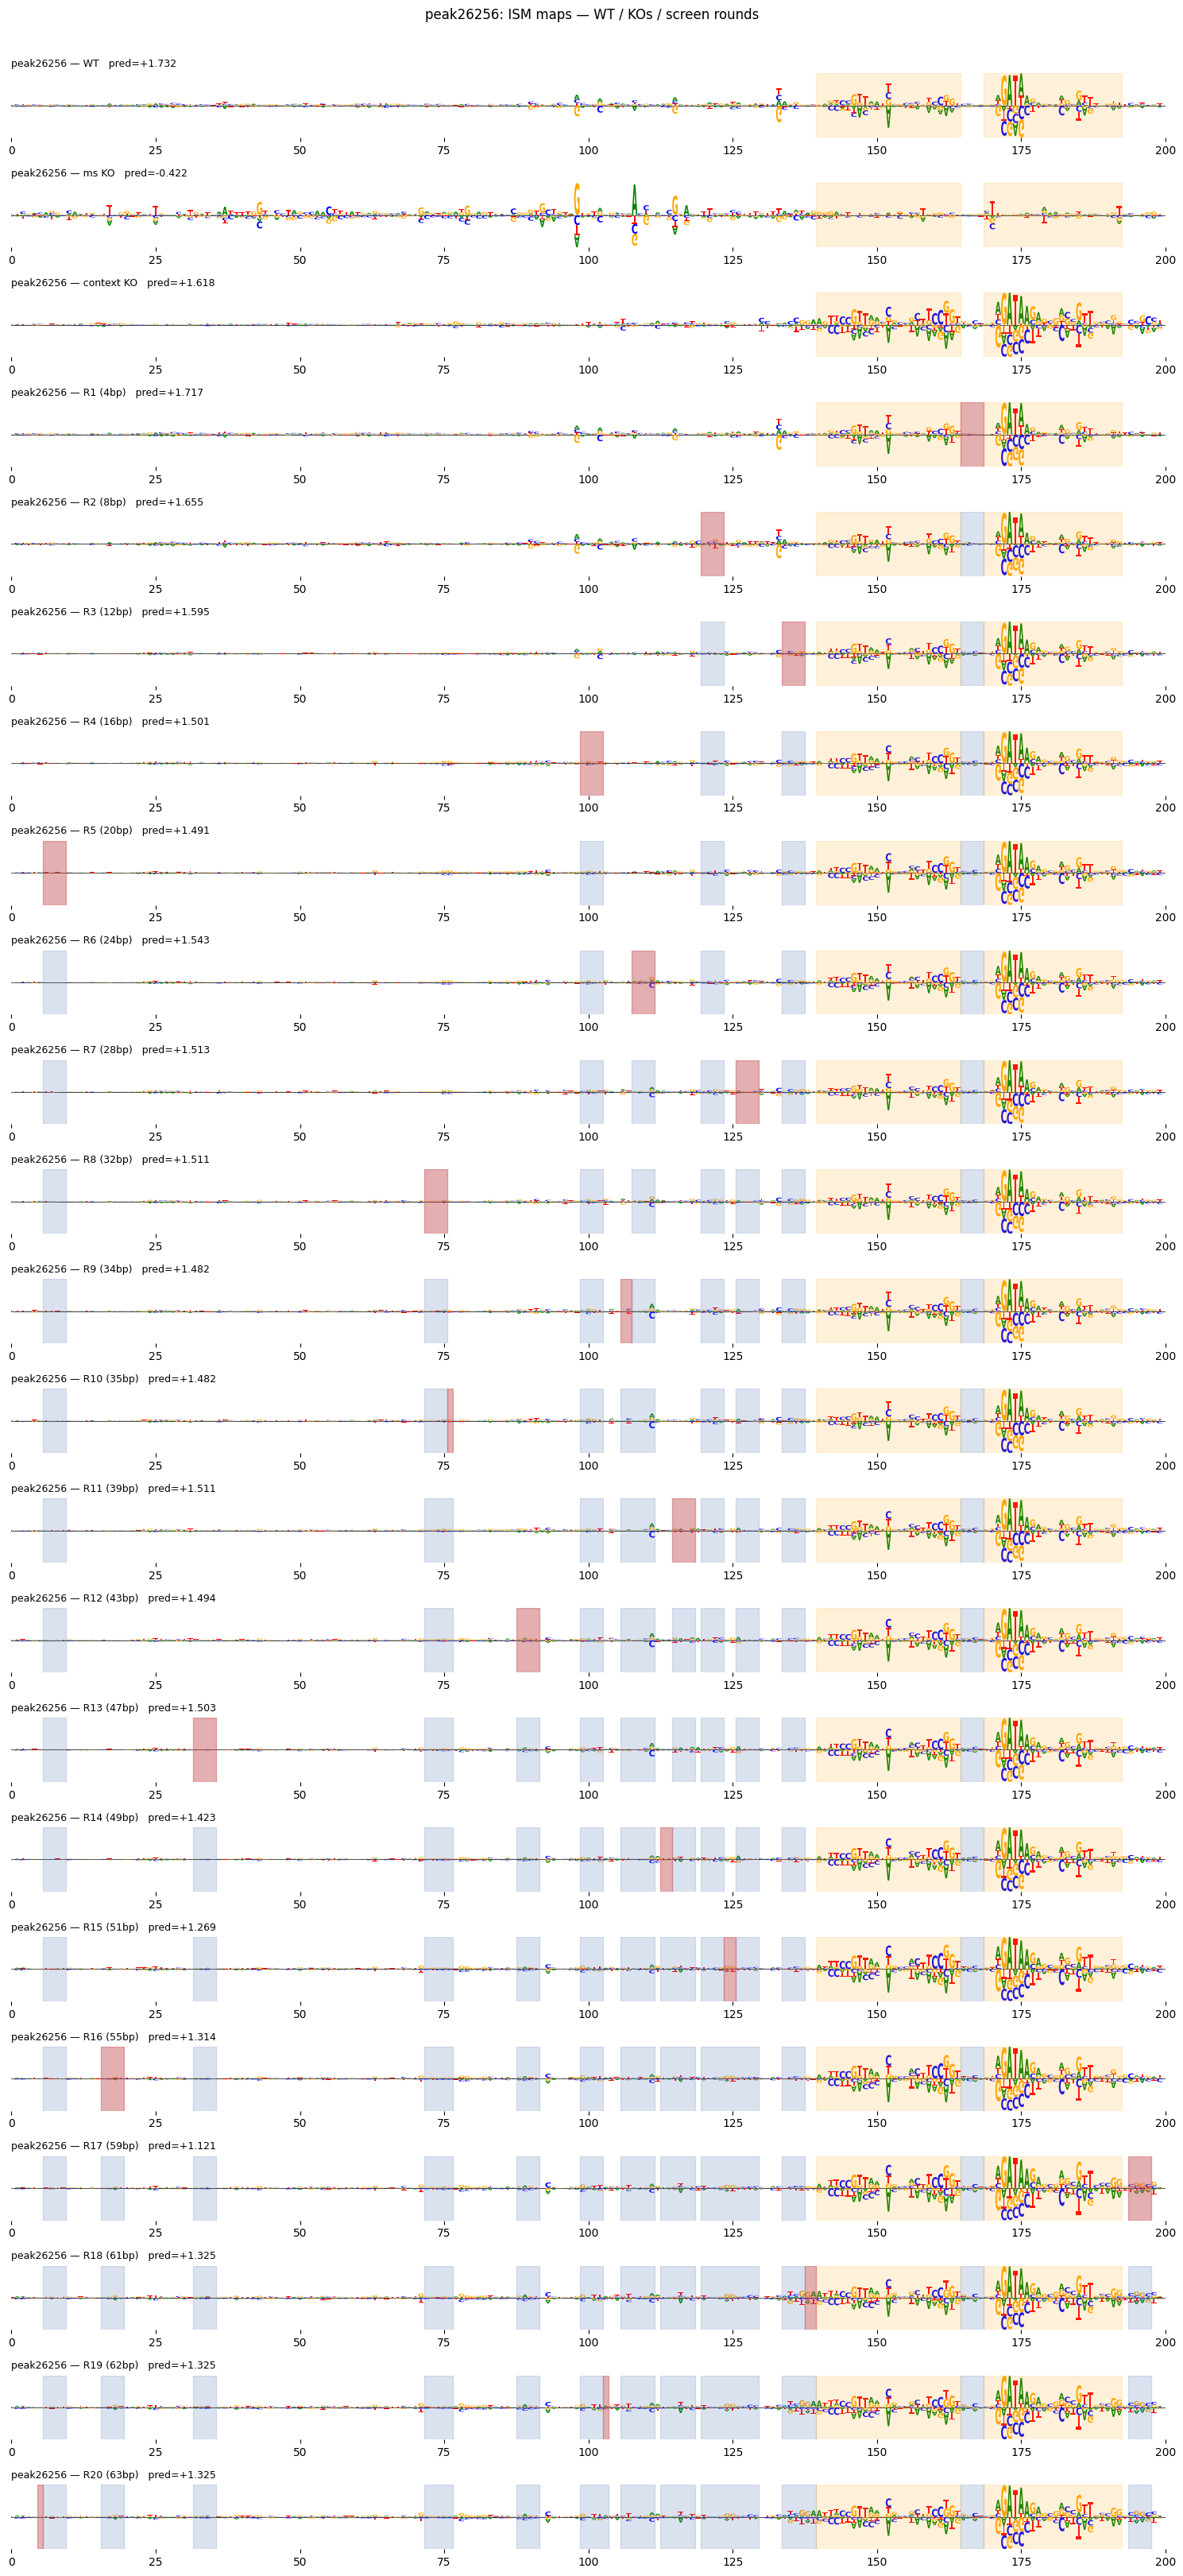

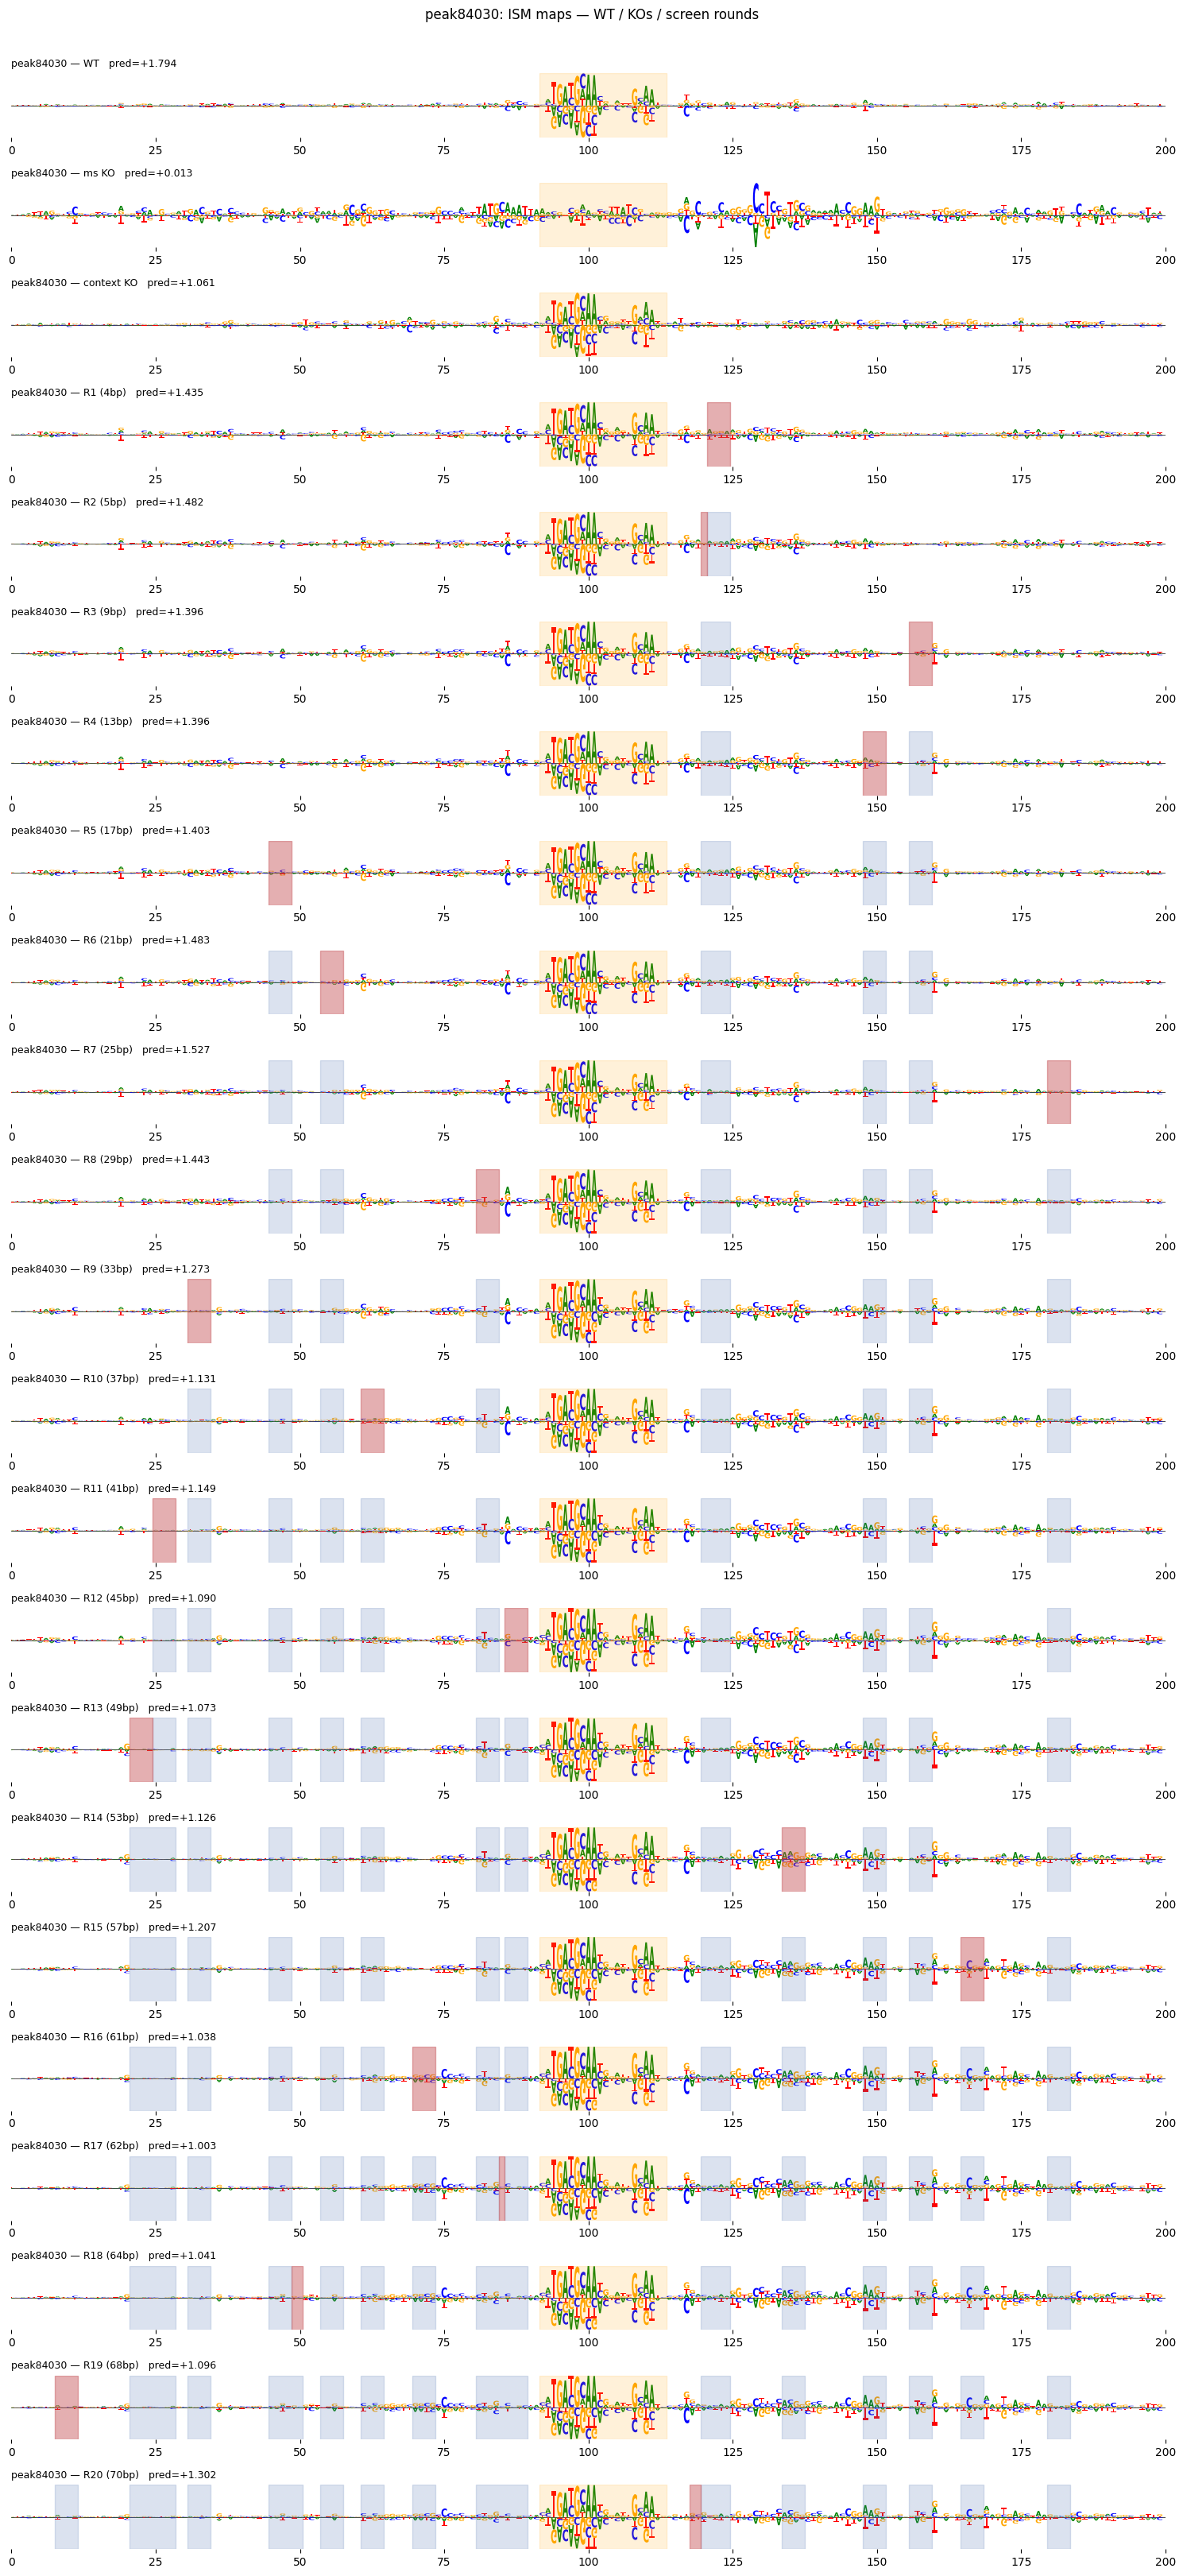

In [33]:
# ISM attribution maps (ism_centered) — the SAME method as the annotated SEAM foregrounds:
# 200bp var region mutated to all 4 bases at every position, insert padded with the K562
# construct suffix, mean-centered across channels. WT / ms KO / context KO / every screen round.
# On round maps: orange = motifs, blue = earlier rounds' 4bp windows, red = this round's new 4bp.
import logomaker

def ism_map(insert, ADAPTER):                          # (4,230) -> (200,4) mean-centered ISM, self-pred
    X = insert.unsqueeze(0).repeat(801, 1, 1).clone()  # row 0 = original, rows 1..800 = (pos,base) mutants
    pos  = np.repeat(np.arange(200), 4); base = np.tile(np.arange(4), 200)
    cols = ADAPTER + pos; rows = 1 + np.arange(800)
    X[rows[:, None], np.arange(4)[None, :], cols[:, None]] = 0.0
    X[rows, base, cols] = 1.0
    preds = predict_k562(X)                             # (801,)
    ism = (preds[1:] - preds[0]).reshape(200, 4)        # effect vs the unmutated seq
    return ism - ism.mean(-1, keepdims=True), float(preds[0])   # mean-center across channels; self-pred

def shade(ax, mask, color, alpha):                     # shade contiguous True spans of a bool[200] mask
    d = np.diff(np.r_[0, mask.astype(int), 0])
    for st, e in zip(np.where(d == 1)[0], np.where(d == -1)[0]):
        ax.axvspan(st - 0.5, e - 0.5, color=color, alpha=alpha)

for peak in ['peak26256', 'peak84030']:
    wt, ADAPTER, mmask = load_peak(peak)
    shuf = dinucleotide_shuffle(wt[:, ADAPTER:ADAPTER + 200].unsqueeze(0), n=1, random_state=0)[0][0]  # (4,200)
    mi, ci = np.where(mmask)[0], np.where(~mmask)[0]
    ms = wt.clone(); ms[:, ADAPTER + mi] = shuf[:, mi]                     # motifs shuffled
    cx = wt.clone(); cx[:, ADAPTER + ci] = shuf[:, ci]                     # context shuffled
    seqs = [('WT', wt.clone(), None, None), ('ms KO', ms, None, None), ('context KO', cx, None, None)]
    for i, pos_bool in enumerate(screen_pos[peak]):                        # each greedy screen round
        s = wt.clone(); idx = np.where(pos_bool)[0]
        s[:, ADAPTER + idx] = shuf[:, idx]
        prev = screen_pos[peak][i - 1] if i > 0 else np.zeros(200, bool)   # earlier rounds' windows
        seqs.append((f'R{i+1} ({int(pos_bool.sum())}bp)', s, prev, pos_bool & ~prev))  # ..., prev, new 4bp

    fig, axes = plt.subplots(len(seqs), 1, figsize=(15, 1.4 * len(seqs)), squeeze=False)
    for ax, (lab, s, prev, new) in zip(axes[:, 0], seqs):
        a, pred = ism_map(s, ADAPTER)                                      # own scale per map, not normalized
        logomaker.Logo(pd.DataFrame(a, columns=list('ACGT')), ax=ax)
        shade(ax, mmask, 'orange', 0.15)                                   # motifs
        if prev is not None: shade(ax, prev, '#4c72b0', 0.20)             # earlier rounds' 4bp windows
        if new  is not None: shade(ax, new,  '#c44e52', 0.45)             # this round's new 4bp window
        ax.set_title(f'{peak} — {lab}   pred={pred:+.3f}', loc='left', fontsize=9)
        ax.set_xlim(0, 200); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)
    fig.suptitle(f'{peak}: ISM maps — WT / KOs / screen rounds', y=1.005)
    fig.tight_layout()

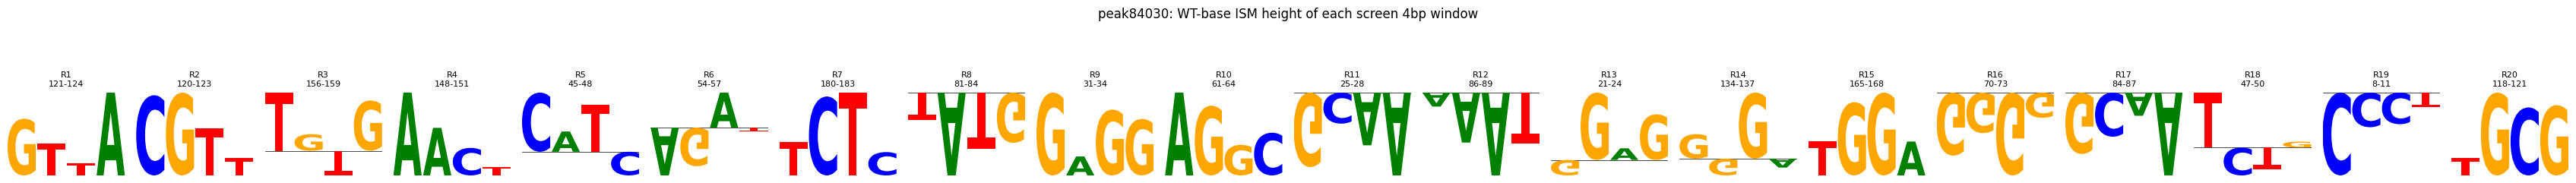

In [35]:
# peak84030: each greedy 4bp window as a logo — only the WT base at each position, drawn at its ISM height.
# (uses the exact chosen window start, so every window is the full 4bp; needs re-running the screen cell.)
peak = 'peak84030'
wt, ADAPTER, mmask = load_peak(peak)
wt_ism, _ = ism_map(wt, ADAPTER)                                     # (200,4) WT ISM attribution over var region
wt_oh = wt[:, ADAPTER:ADAPTER + 200].T.numpy()                      # (200,4) WT one-hot, ACGT
wt_proj = wt_ism * wt_oh                                            # keep only the WT base, at its ISM value
starts = screen_win[peak]                                          # chosen 4bp window starts

fig, axes = plt.subplots(1, len(starts), figsize=(1.7 * len(starts), 2.0), squeeze=False)
for ax, (rnd, st) in zip(axes[0], enumerate(starts, 1)):
    logomaker.Logo(pd.DataFrame(wt_proj[st:st + WIN], columns=list('ACGT')), ax=ax)   # WT letters only
    ax.set_title(f'R{rnd}\n{st}-{st + WIN - 1}', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
fig.suptitle(f'{peak}: WT-base ISM height of each screen 4bp window', y=1.18)
fig.tight_layout()